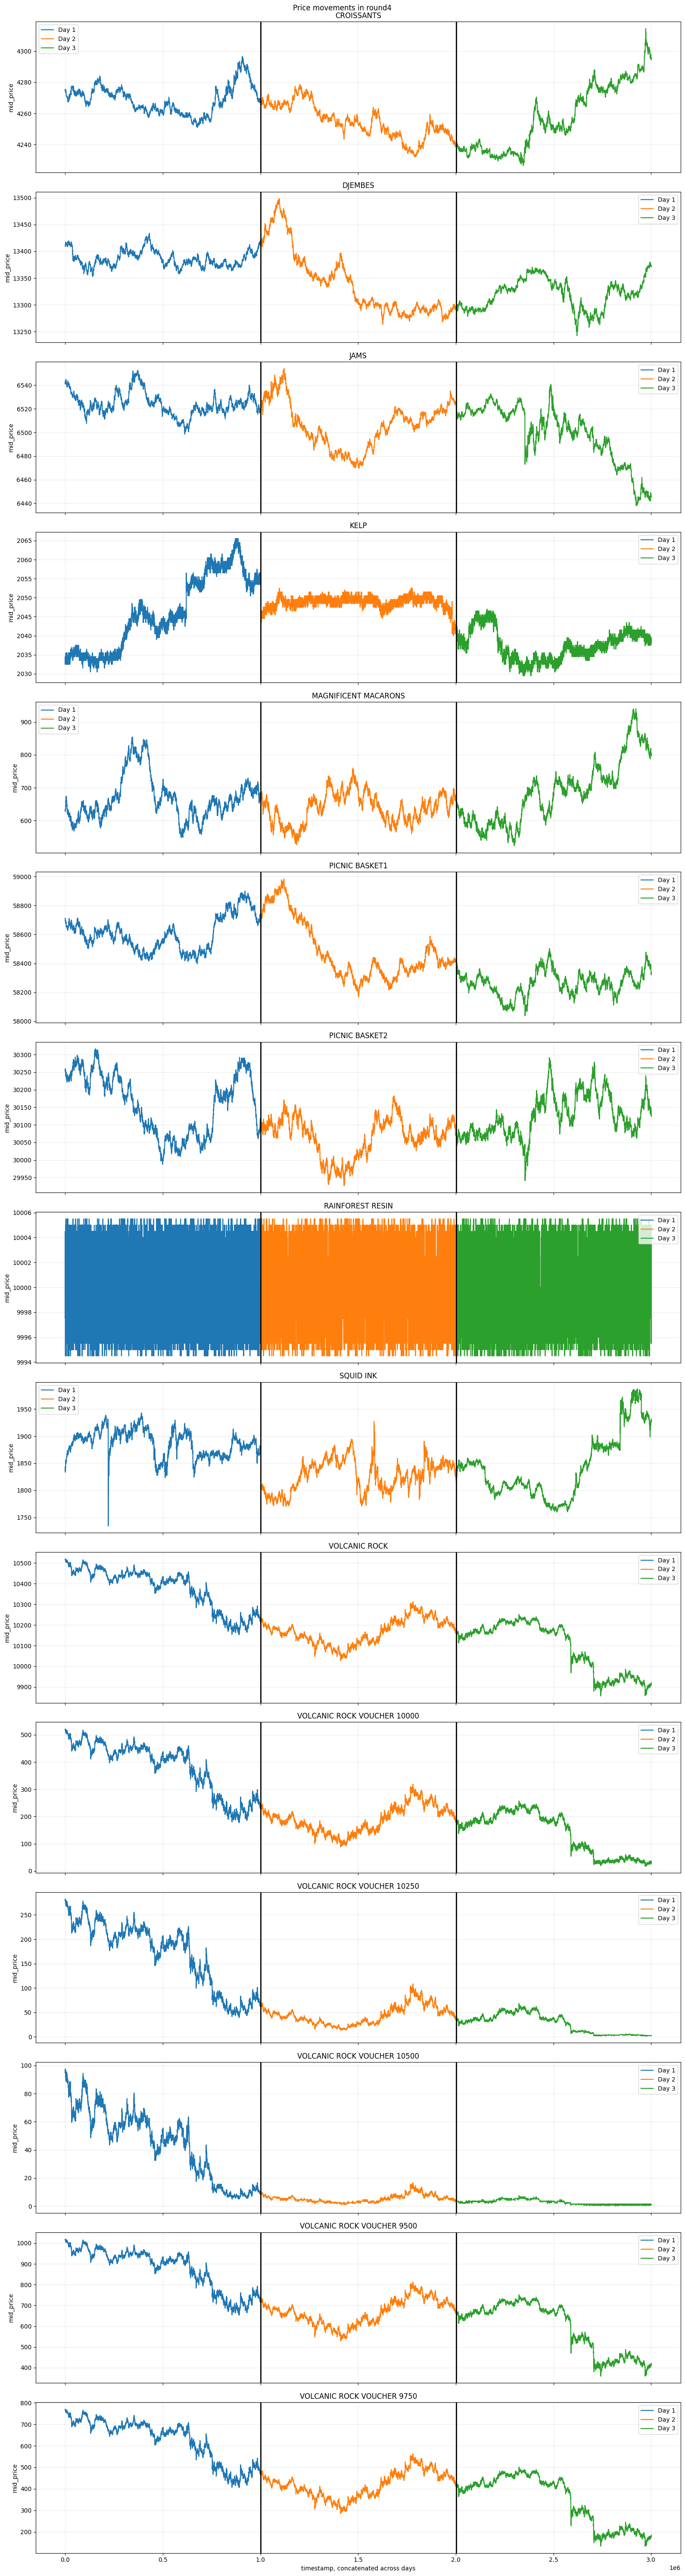

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd

ROUND_NUMBER = 4
candidate_folders = [
    Path(f"round{ROUND_NUMBER}"),
    Path("2025") / f"round{ROUND_NUMBER}",
]
ROUND_FOLDER = next((folder for folder in candidate_folders if folder.exists()), None)
if ROUND_FOLDER is None:
    raise FileNotFoundError(f"Could not find the round{ROUND_NUMBER} folder. Tried: round{ROUND_NUMBER}, 2025/round{ROUND_NUMBER}")

PRICE_FILES = sorted(ROUND_FOLDER.glob(f"prices_round_{ROUND_NUMBER}_day_*.csv"))
if not PRICE_FILES:
    raise FileNotFoundError(f"No price CSV files found in {ROUND_FOLDER}")

DAY_RE = re.compile(r"day_(-?\d+)\.csv$")
DAY_LABELS = []
frames = []
for file_path in PRICE_FILES:
    match = DAY_RE.search(file_path.name)
    if match is None:
        continue

    day = int(match.group(1))
    DAY_LABELS.append(day)

    df = pd.read_csv(file_path, sep=";")
    df["day"] = day
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df["mid_price"] = pd.to_numeric(df["mid_price"], errors="coerce")
    frames.append(df[["day", "timestamp", "product", "mid_price"]])

if not frames:
    raise ValueError(f"No valid price data found in {ROUND_FOLDER}")

DAY_LABELS = sorted(set(DAY_LABELS))
prices = pd.concat(frames, ignore_index=True).dropna(subset=["timestamp", "mid_price"])
prices["timestamp"] = prices["timestamp"].astype(float)
products = sorted(prices["product"].dropna().unique())

# Build a continuous x-axis for the days and leave a visible gap between them.
gap = 1000.0
x_offsets = {}
separator_positions = []
current_offset = 0.0
for day in DAY_LABELS:
    day_prices = prices[prices["day"] == day]
    max_timestamp = float(day_prices["timestamp"].max()) if not day_prices.empty else 0.0
    x_offsets[day] = current_offset
    separator_positions.append(current_offset + max_timestamp + gap / 2)
    current_offset += max_timestamp + gap

fig, axes = plt.subplots(len(products), 1, figsize=(16, max(4, 4 * len(products))), sharex=True)
if len(products) == 1:
    axes = [axes]

cmap = plt.get_cmap("tab10")
color_map = {day: cmap(i % cmap.N) for i, day in enumerate(DAY_LABELS)}

for ax, product in zip(axes, products):
    product_prices = prices[prices["product"] == product].sort_values(["day", "timestamp"])

    for day in DAY_LABELS:
        day_prices = product_prices[product_prices["day"] == day].sort_values("timestamp")
        if day_prices.empty:
            continue

        x_values = day_prices["timestamp"] + x_offsets[day]
        ax.plot(
            x_values,
            day_prices["mid_price"],
            color=color_map[day],
            linewidth=1.6,
            label=f"Day {day}",
        )

    for separator in separator_positions[:-1]:
        ax.axvline(separator, color="black", linewidth=2)

    ax.set_title(product.replace("_", " "))
    ax.set_ylabel("mid_price")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)

axes[-1].set_xlabel("timestamp, concatenated across days")
fig.suptitle(f"Price movements in {ROUND_FOLDER.name}", y=0.995)
fig.tight_layout()
plt.show()


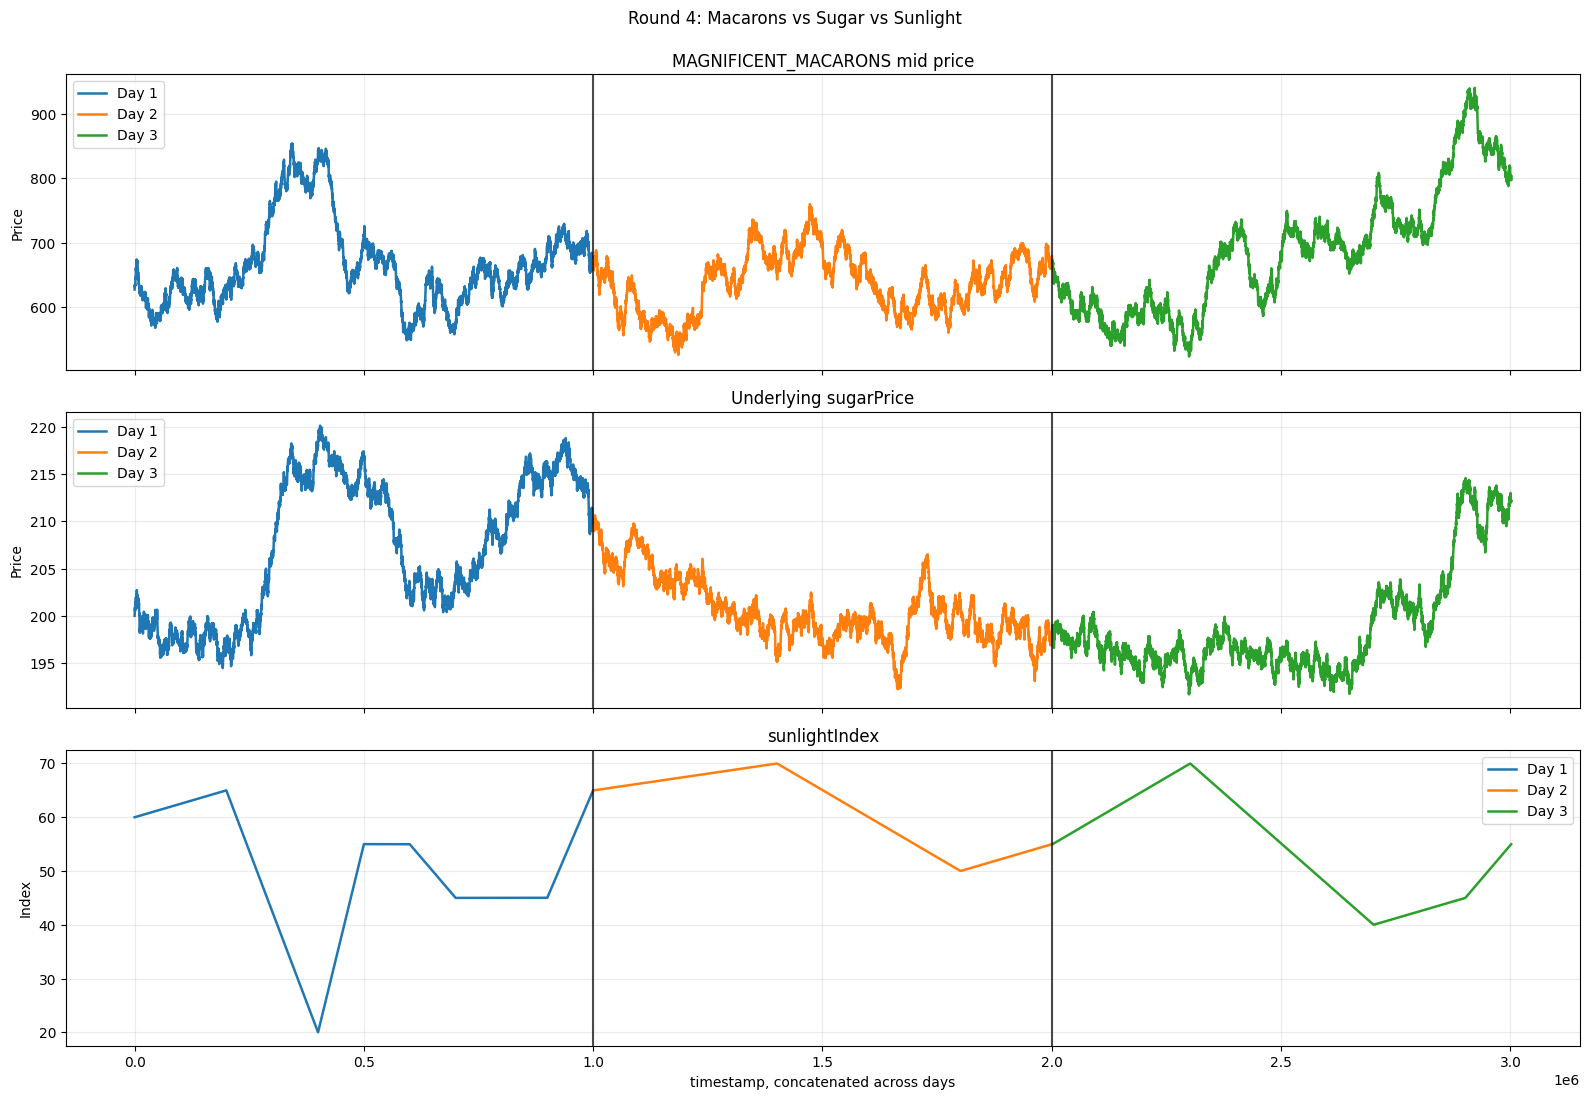

In [1]:
# Graph MAGNIFICENT_MACARONS mid price vs sugarPrice and sunlightIndex
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd

ROUND_NUMBER = 4
candidate_folders = [
    Path(f"round{ROUND_NUMBER}"),
    Path("2025") / f"round{ROUND_NUMBER}",
]
ROUND_FOLDER = next((folder for folder in candidate_folders if folder.exists()), None)
if ROUND_FOLDER is None:
    raise FileNotFoundError(f"Could not find the round{ROUND_NUMBER} folder.")

price_files = sorted(ROUND_FOLDER.glob(f"prices_round_{ROUND_NUMBER}_day_*.csv"))
obs_files = sorted(ROUND_FOLDER.glob(f"observations_round_{ROUND_NUMBER}_day_*.csv"))
if not price_files or not obs_files:
    raise FileNotFoundError("Missing price or observation files for this round.")

day_re = re.compile(r"day_(-?\d+)\.csv$")

# Load MACARONS mid prices from price files.
mac_frames = []
for file_path in price_files:
    m = day_re.search(file_path.name)
    if m is None:
        continue
    day = int(m.group(1))
    d = pd.read_csv(file_path, sep=";")
    d = d[d["product"] == "MAGNIFICENT_MACARONS"].copy()
    if d.empty:
        continue
    d["day"] = day
    d["timestamp"] = pd.to_numeric(d["timestamp"], errors="coerce")
    d["mid_price"] = pd.to_numeric(d["mid_price"], errors="coerce")
    mac_frames.append(d[["day", "timestamp", "mid_price"]])

if not mac_frames:
    raise ValueError("No MAGNIFICENT_MACARONS rows found.")

mac = pd.concat(mac_frames, ignore_index=True).dropna(subset=["timestamp", "mid_price"])

# Load sugar and sunlight from observation files.
obs_frames = []
for file_path in obs_files:
    m = day_re.search(file_path.name)
    if m is None:
        continue
    day = int(m.group(1))
    d = pd.read_csv(file_path)
    d["day"] = day
    d["timestamp"] = pd.to_numeric(d["timestamp"], errors="coerce")
    d["sugarPrice"] = pd.to_numeric(d["sugarPrice"], errors="coerce")
    d["sunlightIndex"] = pd.to_numeric(d["sunlightIndex"], errors="coerce")
    obs_frames.append(d[["day", "timestamp", "sugarPrice", "sunlightIndex"]])

obs = pd.concat(obs_frames, ignore_index=True).dropna(subset=["timestamp"])

# Build a continuous x-axis across days.
days = sorted(set(mac["day"]).intersection(set(obs["day"])))
if not days:
    raise ValueError("No overlapping day values between prices and observations.")

gap = 1000.0
x_offsets = {}
separator_positions = []
current_offset = 0.0
for day in days:
    max_ts_mac = mac.loc[mac["day"] == day, "timestamp"].max()
    max_ts_obs = obs.loc[obs["day"] == day, "timestamp"].max()
    max_timestamp = float(pd.Series([max_ts_mac, max_ts_obs]).max())
    x_offsets[day] = current_offset
    separator_positions.append(current_offset + max_timestamp + gap / 2)
    current_offset += max_timestamp + gap

mac["x"] = mac.apply(lambda r: r["timestamp"] + x_offsets[r["day"]], axis=1)
obs["x"] = obs.apply(lambda r: r["timestamp"] + x_offsets[r["day"]], axis=1)

fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)

for day in days:
    mday = mac[mac["day"] == day].sort_values("timestamp")
    oday = obs[obs["day"] == day].sort_values("timestamp")

    axes[0].plot(mday["x"], mday["mid_price"], linewidth=1.8, label=f"Day {day}")
    axes[1].plot(oday["x"], oday["sugarPrice"], linewidth=1.8, label=f"Day {day}")
    axes[2].plot(oday["x"], oday["sunlightIndex"], linewidth=1.8, label=f"Day {day}")

for separator in separator_positions[:-1]:
    for ax in axes:
        ax.axvline(separator, color="black", linewidth=1.5, alpha=0.7)

axes[0].set_title("MAGNIFICENT_MACARONS mid price")
axes[1].set_title("Underlying sugarPrice")
axes[2].set_title("sunlightIndex")

axes[0].set_ylabel("Price")
axes[1].set_ylabel("Price")
axes[2].set_ylabel("Index")
axes[2].set_xlabel("timestamp, concatenated across days")

for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend(loc="best")

fig.suptitle(f"Round {ROUND_NUMBER}: Macarons vs Sugar vs Sunlight", y=0.995)
fig.tight_layout()
plt.show()